# CivicRoute AI Assessment

**Student name:**  Rabbia Ahmed
**Student number:**  
**GitHub repository:**

This notebook adapts the supplied course starter. It trains one small classifier
on the synthetic educational dataset. The goal is to recommend a request
category for a council employee to review, rather than route cases automatically.

The code produces inspection evidence, training curves, a confusion matrix and
test predictions. Read the outputs alongside the interpretation notes below.


## Step 2: Inspect and prepare the data with Pandas and NumPy

### 2.1 Load and inspect the supplied dataset

Show the dataset shape, field names, data types, target-category counts and missing-value summary.


In [1]:
from pathlib import Path
import os
import json
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_SEED = 2026
DATA_PATH = Path("data/civic_requests_prepared.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("civic_requests_prepared.csv")
OUTPUTS = Path("outputs")
OUTPUTS.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
print("Fields:", df.columns.tolist())
print("\nData types:\n", df.dtypes.to_string())
print("\nCategory counts:\n", df["category_label"].value_counts().to_string())
print("\nMissing values:\n", df.isna().sum().to_string())
print("\nPreview:\n", df.head(3).to_string(index=False))
print("Duplicate rows:", df.duplicated().sum())
df.isna().sum().rename("missing_count").to_csv(OUTPUTS / "missing_values.csv")


Original shape: (600, 13)
Fields: ['request_id', 'created_hour', 'neighbourhood', 'channel', 'urgency_level', 'recent_rain_flag', 'night_report_flag', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'category_label']

Data types:
 request_id                   object
created_hour                  int64
neighbourhood                object
channel                      object
urgency_level                object
recent_rain_flag             object
night_report_flag            object
repeat_report_count           int64
image_quality_score         float64
nearby_asset_age_years      float64
description_word_count        int64
previous_resolution_days    float64
category_label               object

Category counts:
 category_label
pothole               150
water_leak            150
broken_streetlight    150
illegal_dumping       150

Missing values:
 request_id                   0
created_hour                 0
neigh

### 2.2 Select the fields and identify the target

The target is `category_label`. I exclude `request_id` because it is an
identifier. Its ordered values must not become a shortcut to the category.
I keep `created_hour` and exclude `night_report_flag`, which is derived from it.
I leave neighbourhood out of this initial model to avoid directly learning
location-based reporting patterns. This does not remove all possible bias:
channel and other fields can still act as proxies, so subgroup checks matter.

`previous_resolution_days` describes a previous similar case, according to the
dictionary. It is usable only if that history was available when a new request
arrived. The real system would need that timing verified.


In [2]:
TARGET = "category_label"
numeric_fields = [
    "created_hour", "repeat_report_count", "image_quality_score",
    "nearby_asset_age_years", "description_word_count", "previous_resolution_days",
]
categorical_fields = ["channel", "urgency_level", "recent_rain_flag"]
input_fields = numeric_fields + categorical_fields
work = df.loc[:, input_fields + [TARGET]].copy()
print("Inputs:", input_fields)
print("Target:", TARGET)
print("Selected shape:", work.shape)


Inputs: ['created_hour', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'channel', 'urgency_level', 'recent_rain_flag']
Target: category_label
Selected shape: (600, 10)


### 2.3 Handle the small number of missing values

I split the row indices first: 70% training, 15% validation and 15% test.
Stratification keeps all four categories represented. The seed fixes the split.
This happens before calculating replacement values to prevent test leakage.

Numerical gaps use the training median, which is less sensitive to extreme
values than the mean. Channel gaps use the training mode. Only 4 channel
values are missing, but mode imputation can still overrepresent a common
channel. Dropping rows would throw away otherwise usable examples.


In [3]:
train_idx, heldout_idx = train_test_split(
    work.index.to_numpy(), test_size=0.30, random_state=RANDOM_SEED,
    stratify=work[TARGET],
)
val_idx, test_idx = train_test_split(
    heldout_idx, test_size=0.50, random_state=RANDOM_SEED,
    stratify=work.loc[heldout_idx, TARGET],
)
before_missing = work[input_fields].isna().sum()
medians = work.loc[train_idx, numeric_fields].median()
modes = work.loc[train_idx, categorical_fields].mode().iloc[0]
work[numeric_fields] = work[numeric_fields].fillna(medians)
work[categorical_fields] = work[categorical_fields].fillna(modes)
print(pd.DataFrame({"before": before_missing,
                    "after": work[input_fields].isna().sum()}).to_string())
print("\nTraining medians:\n", medians.to_string())
print("\nTraining modes:\n", modes.to_string())


                          before  after
created_hour                   0      0
repeat_report_count            0      0
image_quality_score           10      0
nearby_asset_age_years         0      0
description_word_count         0      0
previous_resolution_days       9      0
channel                        4      0
urgency_level                  0      0
recent_rain_flag               0      0

Training medians:
 created_hour                14.000
repeat_report_count          3.000
image_quality_score          0.703
nearby_asset_age_years      21.550
description_word_count      15.000
previous_resolution_days     7.800

Training modes:
 channel             mobile_app
urgency_level           medium
recent_rain_flag            no


### 2.4 Apply simple transformation or encoding

I standardise numerical inputs using only the training mean and standard
deviation. The NumPy subtraction and division operate on the whole array.
One-hot encoding avoids imposing a numerical order on channel or urgency.
The encoded column layout is learned from training data and reused for the
other rows. A new category would map to zeros; a production system should
detect and flag it instead of quietly relying on that fallback.

The four target labels become integers, with the mapping saved explicitly.


In [4]:
numeric_array = work[numeric_fields].to_numpy(dtype=np.float32)
means = numeric_array[train_idx].mean(axis=0)
scales = numeric_array[train_idx].std(axis=0)
scales = np.where(scales == 0, 1.0, scales)
scaled_numbers = (numeric_array - means) / scales

train_dummies = pd.get_dummies(work.loc[train_idx, categorical_fields], dtype=float)
encoded = pd.get_dummies(work[categorical_fields], dtype=float)
encoded = encoded.reindex(columns=train_dummies.columns, fill_value=0)
X = np.column_stack([scaled_numbers, encoded.to_numpy()]).astype(np.float32)
class_names = sorted(work.loc[train_idx, TARGET].unique().tolist())
class_to_id = {name: number for number, name in enumerate(class_names)}
y = work[TARGET].map(class_to_id).to_numpy(dtype=np.int32)
feature_names = numeric_fields + encoded.columns.tolist()


### 2.5 Confirm the model-ready data

Show the final model-ready shape or a small sample of the prepared data. Note what changed from the original dataset and why.


In [5]:
print("X shape:", X.shape, "| y shape:", y.shape)
print("Class mapping:", class_to_id)
print(pd.DataFrame(X[:3], columns=feature_names).round(3).to_string(index=False))
assert np.isfinite(X).all(), "Prepared features must be finite."
assert not work[input_fields].isna().any().any()

split_labels = pd.Series(index=work.index, dtype="object")
for label, indices in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
    split_labels.loc[indices] = label
prepared = work.copy()
prepared.insert(0, "request_id", df["request_id"])
prepared["split"] = split_labels
prepared.to_csv(OUTPUTS / "prepared_data.csv", index=False)
features = pd.DataFrame(X, columns=feature_names)
features.insert(0, "request_id", df["request_id"])
features["target_id"] = y
features["split"] = split_labels
features.to_csv(OUTPUTS / "model_ready_features.csv", index=False)

preprocessing = {
    "numeric_fields": numeric_fields, "categorical_fields": categorical_fields,
    "medians": medians.to_dict(), "modes": modes.to_dict(),
    "means": means.tolist(), "scales": scales.tolist(),
    "encoded_columns": encoded.columns.tolist(), "class_to_id": class_to_id,
}
(OUTPUTS / "preprocessing.json").write_text(json.dumps(preprocessing, indent=2))


X shape: (600, 15) | y shape: (600,)
Class mapping: {'broken_streetlight': 0, 'illegal_dumping': 1, 'pothole': 2, 'water_leak': 3}
 created_hour  repeat_report_count  image_quality_score  nearby_asset_age_years  description_word_count  previous_resolution_days  channel_call_centre  channel_mobile_app  channel_service_office  channel_web_portal  urgency_level_high  urgency_level_low  urgency_level_medium  recent_rain_flag_no  recent_rain_flag_yes
        0.694               -0.109                0.425                   0.006                  -0.477                     0.600                  1.0                 0.0                     0.0                 0.0                 0.0                0.0                   1.0                  0.0                   1.0
       -0.966               -0.109               -0.852                  -0.156                   0.026                    -0.064                  0.0                 1.0                     0.0                 0.0                 

## Step 3: Build one small TensorFlow/Keras model

The model should be deliberately modest. One or two hidden Dense layers are sufficient. No extensive tuning or competing models are required.


### 3.1 Create reproducible training, validation and test data


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print(pd.crosstab(split_labels, work[TARGET]).to_string())
print("TensorFlow:", tf.__version__)


Train: (420, 15) Validation: (90, 15) Test: (90, 15)
category_label  broken_streetlight  illegal_dumping  pothole  water_leak
row_0                                                                   
test                            22               23       23          22
train                          105              105      105         105
validation                      23               22       22          23
TensorFlow: 2.20.0


### 3.2 Define a small Sequential classification model


In [7]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])
model.summary()


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 428 (1.67 KB)
 Trainable params: 428 (1.67 KB)
 Non-trainable params: 0 (0.00 B)


### 3.3 Compile and train the model

Softmax returns four class scores that sum to one. Sparse categorical
cross-entropy matches the integer target labels for this four-class problem.
Adam with a learning rate of 0.001 is a straightforward course-level choice.
The two small hidden layers keep the model modest.

I fix 30 epochs and batches of 32 before looking at test results. Validation
shows training behaviour; the test set is reserved for the final evaluation.
The data pipeline limits background threads for reliable CPU execution.


In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"],
)
def batched_data(inputs, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((inputs, labels))
    if shuffle:
        dataset = dataset.shuffle(len(inputs), seed=RANDOM_SEED)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 1
    return dataset.batch(32).with_options(options)

history = model.fit(
    batched_data(X_train, y_train, shuffle=True),
    validation_data=batched_data(X_val, y_val), epochs=30, shuffle=False, verbose=0,
)
history_table = pd.DataFrame(history.history)
history_table.insert(0, "epoch", np.arange(1, len(history_table) + 1))
history_table.to_csv(OUTPUTS / "training_history.csv", index=False)
print(history_table.iloc[[0, -1]].round(4).to_string(index=False))


 epoch  accuracy   loss  val_accuracy  val_loss
     1    0.2357 1.6639        0.2556    1.6566
    30    0.7619 0.5842        0.7778    0.5830


### 3.4 Show the training and validation behaviour


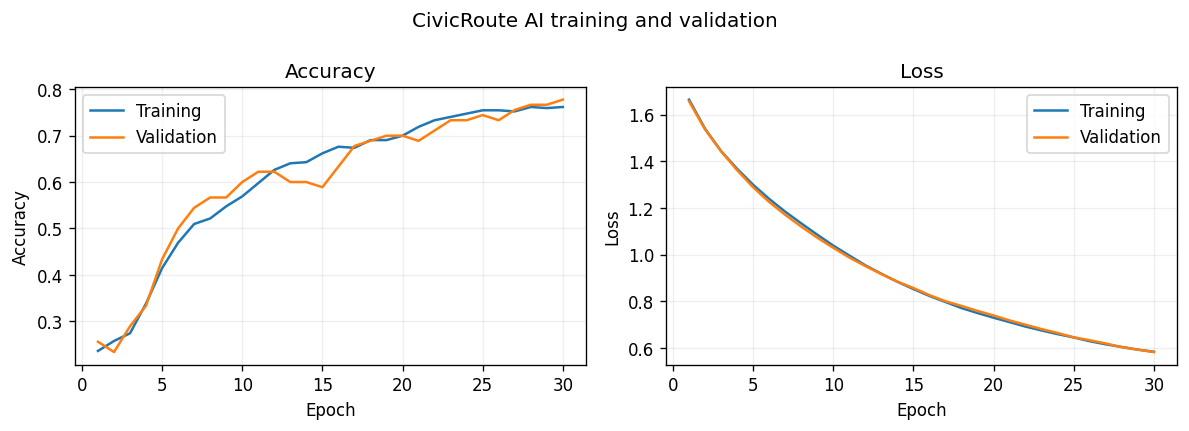

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history_table["epoch"], history_table[metric], label="Training")
    ax.plot(history_table["epoch"], history_table["val_" + metric], label="Validation")
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    ax.legend()
    ax.grid(alpha=0.2)
fig.suptitle("CivicRoute AI training and validation")
fig.tight_layout()
fig.savefig(OUTPUTS / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


### 3.5 Evaluate the prototype

Report overall test accuracy and produce a confusion matrix. These are the main outputs you will use when explaining one strength, one weakness or risky error, and what should happen next.


Test accuracy: 75.56% (68/90)
Test loss: 0.5730
                    precision  recall  f1-score  support
broken_streetlight      0.750   0.818     0.783   22.000
illegal_dumping         0.952   0.870     0.909   23.000
pothole                 0.588   0.435     0.500   23.000
water_leak              0.714   0.909     0.800   22.000
accuracy                0.756   0.756     0.756    0.756
macro avg               0.751   0.758     0.748   90.000
weighted avg            0.752   0.756     0.747   90.000


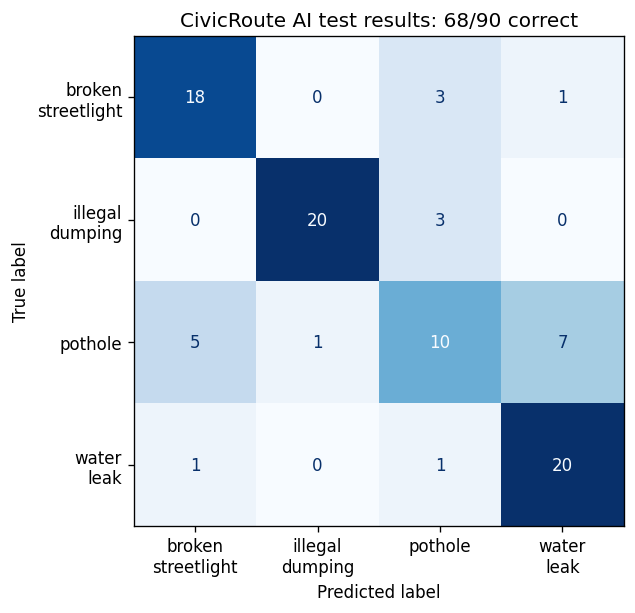

In [10]:
test_loss, test_accuracy = model.evaluate(batched_data(X_test, y_test), verbose=0)
probabilities = model(X_test, training=False).numpy()
predicted_ids = probabilities.argmax(axis=1)
cm = confusion_matrix(y_test, predicted_ids, labels=np.arange(len(class_names)))
report = classification_report(
    y_test, predicted_ids, labels=np.arange(len(class_names)),
    target_names=class_names, output_dict=True, zero_division=0,
)
correct = int((predicted_ids == y_test).sum())
print(f"Test accuracy: {test_accuracy:.2%} ({correct}/{len(y_test)})")
print(f"Test loss: {test_loss:.4f}")
print(pd.DataFrame(report).T.round(3).to_string())

display_names = [name.replace("_", "\n") for name in class_names]
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ConfusionMatrixDisplay(cm, display_labels=display_names).plot(
    ax=ax, cmap="Blues", colorbar=False,
)
ax.set_title(f"CivicRoute AI test results: {correct}/{len(y_test)} correct")
fig.tight_layout()
fig.savefig(OUTPUTS / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(OUTPUTS / "confusion_matrix.csv")

predictions = df.loc[test_idx, ["request_id", "neighbourhood", TARGET]].copy()
predictions["predicted_category"] = [class_names[i] for i in predicted_ids]
predictions["max_softmax_score"] = probabilities.max(axis=1)
predictions["correct"] = predicted_ids == y_test
predictions.to_csv(OUTPUTS / "test_predictions.csv", index=False)
metrics = {
    "seed": RANDOM_SEED, "original_shape": list(df.shape),
    "selected_inputs": input_fields, "encoded_feature_count": int(X.shape[1]),
    "split_sizes": {"train": len(y_train), "validation": len(y_val), "test": len(y_test)},
    "epochs": len(history_table), "parameters": model.count_params(),
    "test_accuracy": float(test_accuracy), "test_loss": float(test_loss),
    "correct_test_predictions": correct, "class_names": class_names,
    "confusion_matrix": cm.tolist(), "classification_report": report,
    "first_epoch": history_table.iloc[0].to_dict(),
    "last_epoch": history_table.iloc[-1].to_dict(),
}
(OUTPUTS / "metrics.json").write_text(json.dumps(metrics, indent=2))
model.save(OUTPUTS / "civicroute_model.keras")


## Step 4 Interpretation and explainability

Training loss falls from 1.6639 to 0.5842 and validation loss from 1.6566
to 0.5830. The curves stay close. Final training accuracy is 76.19% and
validation accuracy is 77.78%. There is no obvious large overfitting gap
in this run, but that does not establish real-world generalisation.

**Test result:** 68 of 90 requests correctly classified, or 75.56% accuracy.
There are 22 incorrect predictions. Illegal dumping is a useful strength:
20/23 cases recognised, 95.24% precision and an F1 score of 0.909.
Potholes are the main weakness: only 10/23 recognised (43.48% recall).
Seven are routed towards water leaks, five towards streetlights and one
towards dumping. A wrong route could delay the appropriate repair.

**Explanation comparison:** LIME is model-agnostic. It perturbs an example's
inputs and fits an interpretable local approximation of the model's prediction.
It can be used with tabular classifiers, but the explanation is approximate,
sampling-dependent and not proof of causality. Grad-CAM uses internal gradients
and spatial feature maps, usually in convolutional image models. This Dense
tabular network has no appropriate spatial maps, and no images were supplied.
LIME would therefore be the more appropriate of these two approaches here.
Neither explanation method has been implemented.

**Further evidence:** representative real requests, reliable labels, time-based
evaluation and subgroup checks. Verify that historical inputs existed at
request creation, investigate the pothole errors and validate softmax calibration
before treating scores as confidence. A confusion matrix identifies errors;
it does not establish why the model made them.

References: [LIME paper](https://arxiv.org/abs/1602.04938) and
[Grad-CAM paper](https://arxiv.org/abs/1610.02391).


## Step 5 Graph-based modelling and GNNs

Proposed node types are requests, neighbourhoods, departments and infrastructure
assets. Useful edges include a request *reported in* a neighbourhood, a request
*concerning* an asset and an asset *maintained by* a department. Requests could
also be connected through the same asset or a verified recurring issue.

A useful question is whether several water-leak reports concern the same pipe.
That relationship could help staff investigate a shared infrastructure problem.
An ordinary graph query might answer it without machine learning.

A GNN could later aggregate information across connected requests and assets
to help predict categories or recognise recurring patterns. That would need
verified relationships, enough labelled cases and careful evaluation. The CSV
has no asset IDs or verified request-to-asset links. For this prototype, a GNN
is not justified. These graph links are proposed extensions, not supplied facts.
No graph or GNN is implemented.


## Final recommendation

Continue with controlled, human-reviewed testing rather than automatic routing.
The prototype learns useful patterns on this educational dataset, especially
for illegal dumping and water leaks. The 75.56% score hides poor pothole recall,
and a 90-row synthetic test set is insufficient evidence for real deployment.

Next, gather representative labelled requests with suitable privacy controls,
verify feature timing, audit errors and evaluate by category, neighbourhood,
channel and later time periods. Staff should confirm suggestions and manually
handle uncertain, unusual or high-risk cases. A confidence threshold needs
validation; softmax scores alone do not justify trusting a route. Measure
whether the workflow improves routing time and correctness for the council.
